In [1]:

# import importlib
# import tree_plot
# importlib.reload(tree_plot)
from tree_plot import *


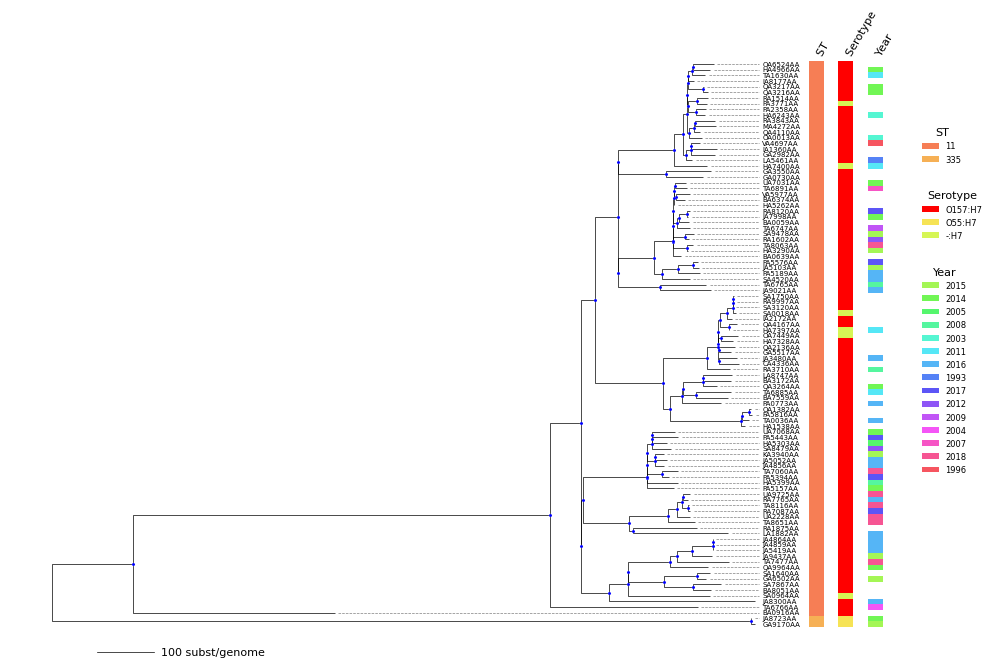

In [2]:

tree = Phylo.read("demo_tree.nwk", format='newick')
metadata = pd.read_csv("demo_metadata.csv", dtype_backend="numpy_nullable")

fig, ax = plt.subplots(figsize=(12,8))
tp = TreePlot(tree)
tp.plot_tree(fig=fig, ax=ax, how='linear', show_nodes=True, node_color='blue', branch_lw=0.5)

tp.add_tip_labels(align_labels=True, fontsize=5)

tp.add_scale(unit="subst/genome", fontsize=8)
prop_color_df = pd.DataFrame({"Property" : ["Serotype"], "Value" : ["O157:H7"], "Color" : ["red"]})
tp.add_genome_properties(properties_df=metadata, prop_color_df=prop_color_df,
                         name_col="Genome", fontsize=8, legend_fontsize=6, legend_margin= 0.1)





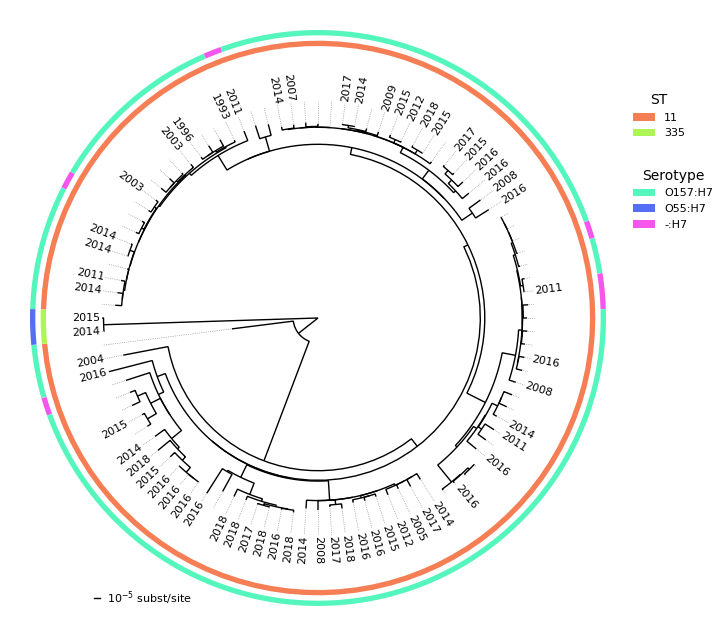

In [3]:

tree = Phylo.read("demo_tree.nwk", format='newick')
metadata = pd.read_csv("demo_metadata.csv", dtype_backend="numpy_nullable")


aln_len = 3.5e6
fig, ax = plt.subplots(figsize=(8,8))
for node in tree.find_clades() : 
    node.branch_length /= aln_len

tp = TreePlot(tree)
tp.plot_tree(fig=fig, ax=ax, how='circular')


year_dic = metadata.set_index("Genome").to_dict()["Year"]
label_func = lambda name : str(year_dic[name] if name in year_dic and year_dic[name] is not None else '')

tp.add_tip_labels(align_labels=True, aln_ls='dotted', fontsize=8, label_func=label_func, circ_padding=0.1)

tp.add_scale(unit="subst/site", fontsize=8)
tp.add_genome_properties(properties_df=metadata[["Genome", "ST", "Serotype"]], 
                         name_col="Genome", fontsize=6, legend_fontsize=8, legend_margin= 0.1)


